In [ ]:
#!unzip "/content/cat_dog.zip" -d "/content/"

Archive:  /content/cat_dog.zip
  inflating: /content/test/cat_s/cat_1.jpg  
  inflating: /content/test/cat_s/cat_106.jpg  
  inflating: /content/test/cat_s/cat_109.jpg  
  inflating: /content/test/cat_s/cat_113.jpg  
  inflating: /content/test/cat_s/cat_114.jpg  
  inflating: /content/test/cat_s/cat_116.jpg  
  inflating: /content/test/cat_s/cat_118.jpg  
  inflating: /content/test/cat_s/cat_119.jpg  
  inflating: /content/test/cat_s/cat_124.jpg  
  inflating: /content/test/cat_s/cat_140.jpg  
  inflating: /content/test/cat_s/cat_147.jpg  
  inflating: /content/test/cat_s/cat_156.jpg  
  inflating: /content/test/cat_s/cat_158.jpg  
  inflating: /content/test/cat_s/cat_162.jpg  
  inflating: /content/test/cat_s/cat_18.jpg  
  inflating: /content/test/cat_s/cat_190.jpg  
  inflating: /content/test/cat_s/cat_203.jpg  
  inflating: /content/test/cat_s/cat_223.jpg  
  inflating: /content/test/cat_s/cat_234.jpg  
  inflating: /content/test/cat_s/cat_244.jpg  
  inflating: /content/test/cat_s

In [ ]:
import os

In [ ]:
len(os.listdir("/content/train/dogs"))

277

In [ ]:
training_data_path = "/content/train"
validation_data_path = "/content/val"

In [ ]:
os.listdir(training_data_path+'/dogs')

['dog_171.jpg',
 'dog_315.jpg',
 'dog_74.jpg',
 'dog_468.jpg',
 'dog_332.jpg',
 'dog_267.jpg',
 'dog_259.jpg',
 'dog_596.jpg',
 'dog_156.jpg',
 'dog_26.jpg',
 'dog_361.jpg',
 'dog_256.jpg',
 'dog_475.jpg',
 'dog_333.jpg',
 'dog_579.jpg',
 'dog_450.jpg',
 'dog_54.jpg',
 'dog_401.jpg',
 'dog_451.jpg',
 'dog_251.jpg',
 'dog_98.jpg',
 'dog_186.jpg',
 'dog_21.jpg',
 'dog_412.jpg',
 'dog_99.jpg',
 'dog_532.jpg',
 'dog_391.jpg',
 'dog_226.jpg',
 'dog_138.jpg',
 'dog_260.jpg',
 'dog_378.jpg',
 'dog_512.jpg',
 'dog_203.jpg',
 'dog_501.jpg',
 'dog_324.jpg',
 'dog_238.jpg',
 'dog_85.jpg',
 'dog_249.jpg',
 'dog_30.jpg',
 'dog_217.jpg',
 'dog_100.jpg',
 'dog_393.jpg',
 'dog_80.jpg',
 'dog_529.jpg',
 'dog_224.jpg',
 'dog_471.jpg',
 'dog_389.jpg',
 'dog_212.jpg',
 'dog_281.jpg',
 'dog_204.jpg',
 'dog_502.jpg',
 'dog_492.jpg',
 'dog_301.jpg',
 'dog_541.jpg',
 'dog_452.jpg',
 'dog_402.jpg',
 'dog_57.jpg',
 'dog_525.jpg',
 'dog_583.jpg',
 'dog_306.jpg',
 'dog_427.jpg',
 'dog_566.jpg',
 'dog_473.jpg',
 '

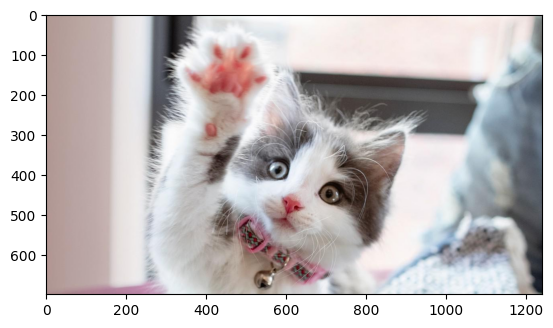

In [ ]:
# cat_image
import numpy as np
import matplotlib.pyplot as plt
cat_image = plt.imread(training_data_path+"/cats/"+"cat_218.jpg")

plt.imshow(cat_image)
plt.show()

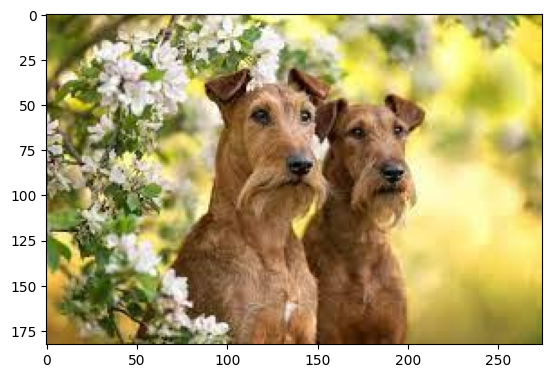

In [ ]:
# dog_image
dog_image = plt.imread(training_data_path+"/dogs"+"/dog_293.jpg")
plt.imshow(dog_image)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)

val_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)

In [ ]:
labels = ['cats','dogs']

In [ ]:
final_train_data = train_data_preprocessing.flow_from_directory(training_data_path,
                                             target_size=(224, 224),
                                             class_mode='binary',
                                             classes = labels,
                                             batch_size = 20)


final_val_data = val_data_preprocessing.flow_from_directory(validation_data_path,
                                             target_size=(224, 224),
                                             class_mode='binary',
                                             classes = labels)


Found 555 images belonging to 2 classes.
Found 138 images belonging to 2 classes.


In [ ]:
# VGG16_Architecture
from tensorflow.keras.applications import VGG16

In [ ]:
vgg16_obj = VGG16(input_shape=(224,224,3) , weights="imagenet" , include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for i in vgg16_obj.layers:
  i.trainable = False

In [ ]:
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.activations import relu,sigmoid,softmax

In [ ]:
one_d_values = Flatten()(vgg16_obj.output)

# give Flatten values to ANN
h1_out = Dense(units=128,kernel_initializer='he_uniform',activation='relu')(one_d_values)
h2_out = Dense(units=64,kernel_initializer='he_uniform',activation='relu')(h1_out)
h3_out = Dense(units=32,kernel_initializer='he_uniform',activation='relu')(h2_out)

output = Dense(units=1,kernel_initializer='glorot_uniform',activation='sigmoid')(h3_out)

model = Model(inputs = vgg16_obj.input , outputs = output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,936,449 (68.42 MB)

 Trainable params: 3,221,761 (12.29 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(final_train_data , validation_data=final_val_data,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7640 - loss: 3.5753 - val_accuracy: 0.8841 - val_loss: 1.0714
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 447ms/step - accuracy: 0.9586 - loss: 0.3212 - val_accuracy: 0.8696 - val_loss: 1.2024
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 442ms/step - accuracy: 0.9514 - loss: 0.3861 - val_accuracy: 0.8623 - val_loss: 1.4989
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 438ms/step - accuracy: 0.9658 - loss: 0.2073 - val_accuracy: 0.8188 - val_loss: 1.4833
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 450ms/step - accuracy: 0.9658 - loss: 0.4251 - val_accuracy: 0.8406 - val_loss: 2.3219


**Do Prediction**

In [ ]:
import cv2

In [ ]:
final_train_data.class_indices

{'cats': 0, 'dogs': 1}

In [ ]:
def pred_image(path_of_image):
  image = cv2.imread(path_of_image,1) # original image
  resized_image = cv2.resize(image , (224,224)) # resizing
  scaled_pixel_values = resized_image / 255  # scaled pixel values
  input_image = np.expand_dims(scaled_pixel_values , axis=0)

  result = model.predict(input_image)
  if result[0][0] > 0.5:
    print(f"Dog")
  else:
    print(f"cat")

  plt.imshow(image[:,:,::-1])
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
cat


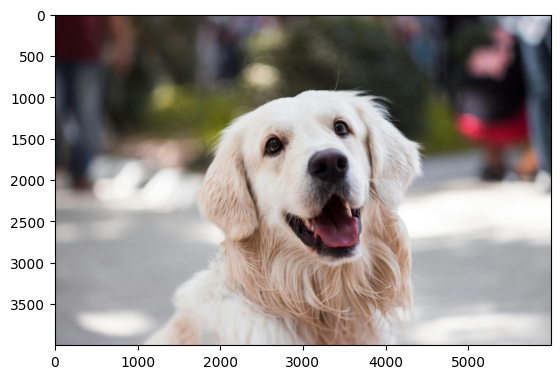

In [ ]:
pred_image("/content/dog.jpg")